In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("spotify_dataset.csv")
df = df.drop_duplicates(subset=['track_name','artists'], keep='first').reset_index(drop=True)

feature_cols = ['acousticness', 'instrumentalness', 'speechiness','energy',
                 'loudness','tempo', 'danceability', 'valence', 
                 'liveness', 'key', 'mode', 'time_signature']

data = df[feature_cols].copy() # dataset copy with just numerical values

In [3]:
# Macro Genres for combining genres
macro = {
    # rock and pop and acoustic
    'rock': "Rock_Pop",
    'punk': "Rock_Pop",
    'guitar': "Rock_Pop",
    'indie': "Rock_Pop",
    'punk_rock' : "Rock_Pop",
    'rock-n-roll': "Rock_Pop",
    'synth-pop': "Rock_Pop",
    'alt-rock': "Rock_Pop",
    'hard-rock': "Rock_Pop",
    'psych-rock': "Rock_Pop",
    'piano': "Rock_Pop",
    'pop': "Rock_Pop",
    'indie': "Rock_Pop",
    'british': "Rock_Pop",
    'alternative': "Rock_Pop",
    'grunge': "Rock_Pop",
    'power-pop': "Rock_Pop",
    'indie-pop': "Rock_Pop",
    'acoustic': "Rock_Pop",
    'singer-songwriter': "Rock_Pop",


    # World
    'indian': "World",
    'swedish': "World",
    'afrobeat': "World",
    'french': "World",
    'samba': "World",
    'turkish': "World",
    'latin': "World",
    'pagode': "World",
    'tango': "World",
    'world-music': "World",
    'latino': "World",
    'spanish': "World",
    'brazil': "World",
    'german': "World",
    'iranian': "World",
    'malay': "World",
    'reggaeton': "World",
    'k-pop': "World",
    'j-pop': "World",
    'j-rock': "World",
    'mandopop': "World",
    'cantopop': "World",

    # Electronic
    'edm': 'Electronic', 
    'house': 'Electronic', 
    'techno': 'Electronic',
    'trance': 'Electronic', 
    'dubstep': 'Electronic', 
    'dance': 'Electronic',
    'deep-house': 'Electronic', 
    'electronic': 'Electronic', 
    'club': 'Electronic',
    'breakbeat': 'Electronic', 
    'drum-and-bass': 'Electronic', 
    'idm': 'Electronic',

    # Metal
    'metal': 'Metal',
    'heavy-metal': 'Metal', 
    'black-metal': 'Metal',
    'death-metal': 'Metal', 
    'metalcore': 'Metal', 
    'grindcore': 'Metal',

    # Jazz, blues, soul, r&b
    'jazz': 'JBSRNB', 'blues': "JBSRNB", 'soul': "JBSRNB",
    'r-n-b': "JBSRNB", 'funk': "JBSRNB", 'disco': "JBSRNB",

    # Country and folk
    'country': 'Country_Folk', 'folk': 'Country_Folk', 'bluegrass': 'Country_Folk',
    'honky-tonk': 'Country_Folk'
}
# anything not in this list becomes "other" - edit later for greater accuracy
df['macro'] = df['track_genre'].map(lambda x: macro.get(x, "Other"))

print("Macro Genre Distribution")
print(df['macro'].value_counts())




Macro Genre Distribution
macro
Other           36123
World           16161
Rock_Pop        10278
Electronic       7957
Metal            4707
Country_Folk     3119
JBSRNB           2999
Name: count, dtype: int64


In [4]:
scaler = StandardScaler()
scaled_data = scaler.fit_transform(data)

macro_dummies = pd.get_dummies(df['macro'], prefix='macro')

macro_weighted = macro_dummies * 10.0

combined_data = np.hstack([scaled_data, macro_weighted])

X = torch.tensor(combined_data).float()


In [5]:
# Data loader 
dataset = TensorDataset(X)
dataloader = DataLoader(dataset, batch_size=64, shuffle= True) # batch size use powers of 2
print(f"Data shape check: {X.shape}")

Data shape check: torch.Size([81344, 19])


Autoencoder Setup

In [6]:
class SongAutoencoder(nn.Module):
    def __init__(self, input_dimension):
        super(SongAutoencoder, self).__init__()

        # Encoder - going to squeeze 12 to 16 to 12
        # expand to 16 to find correlations then map back to 12
        self.encoder = nn.Sequential(
            nn.Linear(input_dimension, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )

        # Decoder - reconstructing 12 features from 4
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dimension)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

In [7]:
model = SongAutoencoder(X.shape[1])
print(model)

SongAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=19, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=19, bias=True)
  )
)


Training Loop

In [8]:
error_formula = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr = 0.001) # why this learning rate

epochs = 30
losses = []

for epoch in range(epochs):
    error_this_epoch = 0

    for batch in dataloader:
        # get one batch of songs (64 each time)
        inputs = batch[0]

        # clear gradients (memory) from previous step
        optimizer.zero_grad()

        # forward pass: model tries reconstructing song "dna"
        outputs = model(inputs)
        
        # calculate error for this specific batch
        loss = error_formula(outputs, inputs)

        # backpropagation - calculate how much to change each weight
        loss.backward()

        # update and adjust weights
        optimizer.step()

        # accumulate error to list
        error_this_epoch += loss.item()

    avg_loss = error_this_epoch / len(dataloader)
    losses.append(avg_loss)

if (epoch + 1) % 5 == 0:
    print(f"Epoch [{epoch + 1}/{epochs}] complete. Error: {avg_loss:.4f}")




Epoch [30/30] complete. Error: 0.0002


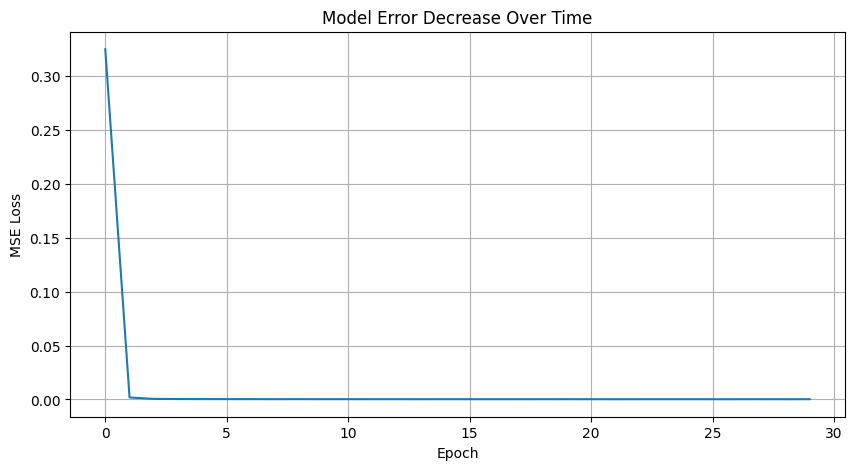

In [9]:
# Plot results
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title("Model Error Decrease Over Time")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()

In [10]:
# Switch model out of training mode and into evaluation
model.eval()

# Generate latent representations (embeddings) - no gradient to save memory
with torch.no_grad():
    # pass entire X tensor through just encoder part
    latent_embeddings = model.encoder(X)

# Convert to Numpy array
embedding_matrix = latent_embeddings.numpy()

print(f"Embedding Matrix Shape: {embedding_matrix.shape}")
print(f"Latent vector for first song: \n{embedding_matrix[0]}")


Embedding Matrix Shape: (81344, 32)
Latent vector for first song: 
[2.5678868 4.435056  2.0928817 3.9214494 2.172432  1.8040441 1.4548571
 4.826728  2.6162553 1.7099875 2.2778149 5.181828  1.867125  0.
 5.164651  4.1018167 4.016886  1.1081278 1.8430521 2.8445432 2.106345
 1.4856691 8.1919775 1.1004682 1.0058202 5.2858167 1.6113955 5.4811335
 2.6745224 2.4074948 0.        4.0520935]


In [11]:
# Recommender Function
from sklearn.metrics.pairwise import cosine_similarity

def get_recommendations(song_index, n_recs=5):
    # Get 4D Latent vector from base song
    # reshape into a 2d array
    query_vector = embedding_matrix[song_index].reshape(1, -1)

    # Calculate similarity score against all songs in df. 1.0 = identical, 0.0 = opposite
    similarity_scores = cosine_similarity(query_vector, embedding_matrix)[0]

    # Find indices of highest scores - use n+1 because base song will be perfect match
    top_indices = similarity_scores.argsort()[-(n_recs + 1):-1][::-1]

    # Display results using original uncopied dataframe:
    base_song = df.iloc[song_index]
    print(f"If you like: '{base_song["track_name"]}' by {base_song['artists']}")
    print("="*50)

    for rank, index in enumerate(top_indices, 1):
        match = df.iloc[index]
        score = similarity_scores[index]
        print(f"{rank}. {match['track_name']} | {match['artists']} ({score:.2%} Match)")
    
    return top_indices

top_indices = get_recommendations(60354)




If you like: 'Take The Long Way Home - 2010 Remastered' by Supertramp
1. Day After Day - Remastered 2010 | Badfinger (99.83% Match)
2. Dawn Over A New World | DragonForce (99.83% Match)
3. Angel Of Small Death & The Codeine Scene | Hozier (99.82% Match)
4. Take It On the Run | REO Speedwagon (99.81% Match)
5. Drive - 2017 Remaster | The Cars (99.80% Match)


In [12]:
# Check the genres of the results
df.iloc[[59882] + list(top_indices)][['track_name', 'artists', 'track_genre']]

,track_name,artists,track_genre
59882,The Logical Song - Remastered 2010,Supertramp,piano
61644,Day After Day - Remastered 2010,Badfinger,power-pop
9771,Dawn Over A New World,DragonForce,british
71311,Angel Of Small Death & The Codeine Scene,Hozier,singer-songwriter
38099,Take It On the Run,REO Speedwagon,hard-rock
38087,Drive - 2017 Remaster,The Cars,hard-rock


In [13]:


# 1. Grab the indices from your last run
comparison_indices = [60354] + list(top_indices)

# 2. Create the vertical table
vibe_dashboard = df.iloc[comparison_indices].copy()
vibe_dashboard.set_index('track_name', inplace=True)

# 3. Transpose and highlight the "Leader" (the first column)
# We round to 3 decimals to keep it readable
vibe_dashboard = vibe_dashboard[feature_cols].T

print("Vibe Comparison Dashboard:")
display(vibe_dashboard.style.background_gradient(axis=1, cmap='viridis').format(precision=3))

Vibe Comparison Dashboard:


track_name,Take The Long Way Home - 2010 Remastered,Day After Day - Remastered 2010,Dawn Over A New World,Angel Of Small Death & The Codeine Scene,Take It On the Run,Drive - 2017 Remaster
acousticness,0.220,0.109,0.020,0.213,0.096,0.115
instrumentalness,0.001,0.001,0.000,0.000,0.000,0.001
speechiness,0.030,0.031,0.029,0.054,0.036,0.041
energy,0.700,0.686,0.660,0.638,0.758,0.703
loudness,-8.838,-7.112,-7.171,-5.754,-5.679,-7.871
tempo,76.790,101.806,79.779,92.644,77.810,83.495
danceability,0.414,0.399,0.382,0.377,0.371,0.261
valence,0.370,0.377,0.244,0.369,0.452,0.405
liveness,0.114,0.112,0.149,0.120,0.116,0.102
key,5.000,5.000,5.000,4.000,7.000,6.000


Song Search Function within dataframe with duplicates removed

In [14]:
# Song search function
def find_song(query):
    return df[df['track_name'].str.contains(query, case=False) | 
              df['artists'].str.contains(query, case=False)][['track_name', 'artists']]

find_song("Supertramp")

,track_name,artists
59779,Give A Little Bit,Supertramp
59878,Breakfast In America - 2010 Remastered,Supertramp
59882,The Logical Song - Remastered 2010,Supertramp
60135,The Logical Song,Supertramp
60273,Goodbye Stranger - 2010 Remastered,Supertramp
60354,Take The Long Way Home - 2010 Remastered,Supertramp


Genre Lookup

In [15]:
def show_unique_genres(dataframe):
    unique_genres = sorted(dataframe['track_genre'].unique())

    print(f"Total Unique Labels: {len(unique_genres)}")
    
    # print in grid w/ 5 columns
    for i in range(0, len(unique_genres), 5):
        print(" | ".join(f"{g:<20}" for g in unique_genres[i:i+5]))

show_unique_genres(df)

Total Unique Labels: 113
acoustic             | afrobeat             | alt-rock             | alternative          | ambient             
anime                | black-metal          | bluegrass            | blues                | brazil              
breakbeat            | british              | cantopop             | chicago-house        | children            
chill                | classical            | club                 | comedy               | country             
dance                | dancehall            | death-metal          | deep-house           | detroit-techno      
disco                | disney               | drum-and-bass        | dub                  | dubstep             
edm                  | electro              | electronic           | emo                  | folk                
forro                | french               | funk                 | garage               | german              
gospel               | goth                 | grindcore            | gr